In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
#1、生成数据
torch.manual_seed(42)
X = 2 * torch.rand(100, 3)
true_W = torch.tensor([[3.0], [2.0], [1.0]])

y = X @ true_W + 0.5 * torch.randn(100, 1)



In [3]:
#2、定义模型
model = nn.Linear(in_features=3, out_features=1, bias=False)


In [4]:
#3、定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


In [5]:
#4、训练模型
for epoch in range(500):
    #前向传播
    y_pred = model(X)
    loss = criterion(y_pred, y)
    #反向传播和优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")
        

Epoch 0: Loss = 42.5881
Epoch 100: Loss = 0.3884
Epoch 200: Loss = 0.2706
Epoch 300: Loss = 0.2359
Epoch 400: Loss = 0.2256


In [6]:
model.weight.data

tensor([[2.9422, 2.0105, 1.1093]])

In [7]:
#5、查看结果
print("真实权重：", true_W.flatten().tolist())
print("模型学到的权重：", model.weight.data.flatten().tolist())

真实权重： [3.0, 2.0, 1.0]
模型学到的权重： [2.9422035217285156, 2.0104775428771973, 1.1093419790267944]


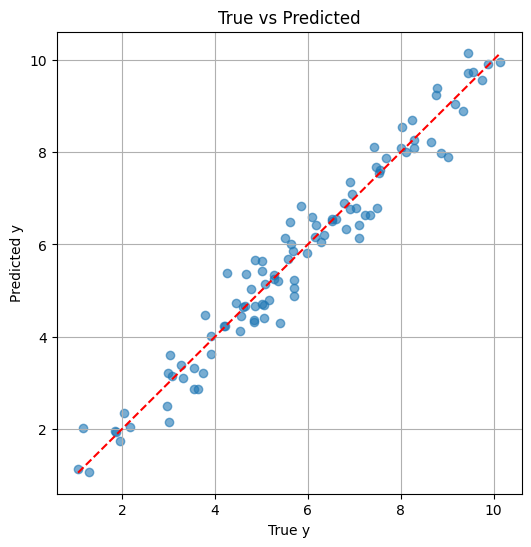

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y.detach().numpy(), y_pred.detach().numpy(), alpha=0.6)
min_val = min(y.min().item(), y_pred.min().item())
max_val = max(y.max().item(), y_pred.max().item())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("True vs Predicted")
plt.grid(True)
plt.show()